# Fraud Prediction Using Skewed Data — Low-Compute Colab Version

This notebook is based on the IBM `Fraud_Detection.ipynb` baseline and is adapted for limited Google Colab computing power.

It:
- loads the full ULB `creditcard.csv` dataset from Google Drive;
- creates and saves a stratified 70% training / 20% test / 10% final validation split;
- keeps the final validation set completely untouched;
- uses only a stratified **20% subset of the training set** for Phase 1 baseline model training;
- uses only a stratified **20% subset of the test set** for faster baseline evaluation;
- applies undersampling and SMOTE only to the reduced training subset;
- uses smaller model settings to reduce runtime and memory use.

The full split files remain saved in Google Drive for later project phases.


## 1. Setup
To prepare your environment, you need to install some packages.

### 1.1 Install the necessary packages

You need the latest versions of these packages:<br>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## 2. Read the Data from Google Drive

Place `creditcard.csv` in your Google Drive.  
Update `DATA_PATH` below if your folder is different.

The notebook will also save:
- `training_data.csv`
- `test_data.csv`
- `validation_data.csv`

The validation dataset is created once and is not used by the modeling cells below.


In [2]:
from google.colab import drive
from pathlib import Path
import pandas as pd

drive.mount('/content/drive')

# CHANGE THIS PATH ONLY IF YOUR GOOGLE DRIVE FOLDER IS DIFFERENT
DATA_PATH = "/content/drive/MyDrive/DS340W/creditcard.csv"
OUTPUT_FOLDER = "/content/drive/MyDrive/DS340W"

df_data_2 = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df_data_2.shape)
display(df_data_2.head())


Mounted at /content/drive
Dataset loaded successfully.
Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. Assign a new name for the dataframe

In [3]:
# Rename the dataframe to df
df = df_data_2.copy()

required_columns = {"Time", "Amount", "Class"} | {f"V{i}" for i in range(1, 29)}
missing_columns = required_columns - set(df.columns)

if missing_columns:
    raise ValueError(f"Missing expected columns: {sorted(missing_columns)}")

print("Dataset ready:", df.shape)
print("\nClass distribution:")
print(df["Class"].value_counts())


Dataset ready: (284807, 31)

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64


## 4. Descriptive statistics on the data

In [4]:
print("Time")
print(df.Time.describe())
print("V1")
print(df.V1.describe())
print("Amount")
print(df.Amount.describe())
print("Class")
print(df.Class.describe())
print("Number of Class values:", df.Class.nunique())
print("ALL")
print(df.describe())


Time
count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64
V1
count    2.848070e+05
mean     1.168375e-15
std      1.958696e+00
min     -5.640751e+01
25%     -9.203734e-01
50%      1.810880e-02
75%      1.315642e+00
max      2.454930e+00
Name: V1, dtype: float64
Amount
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64
Class
count    284807.000000
mean          0.001727
std           0.041527
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: Class, dtype: float64
Number of Class values: 2
ALL
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+

## 5. Use Histogram to visualize

<Axes: >

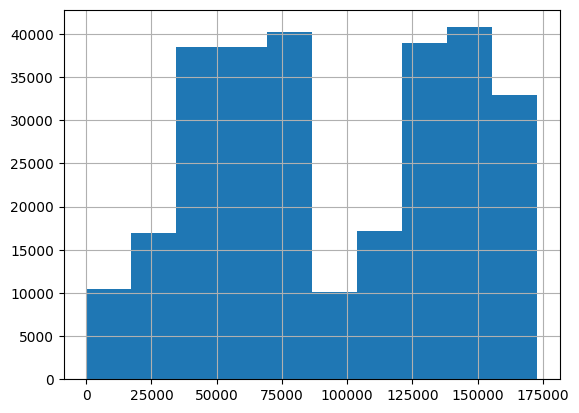

In [5]:
df.Time.hist()

<Axes: >

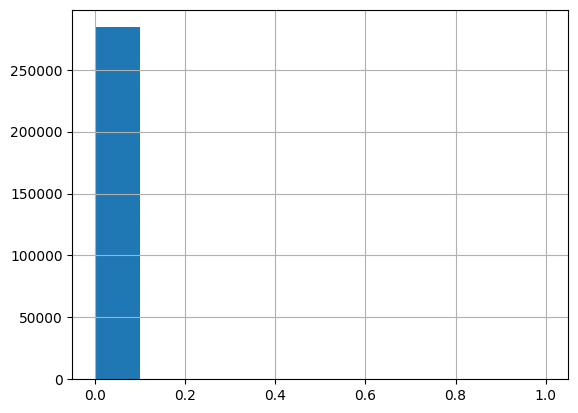

In [6]:
df.Class.hist()

array([<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>],
      dtype=object)

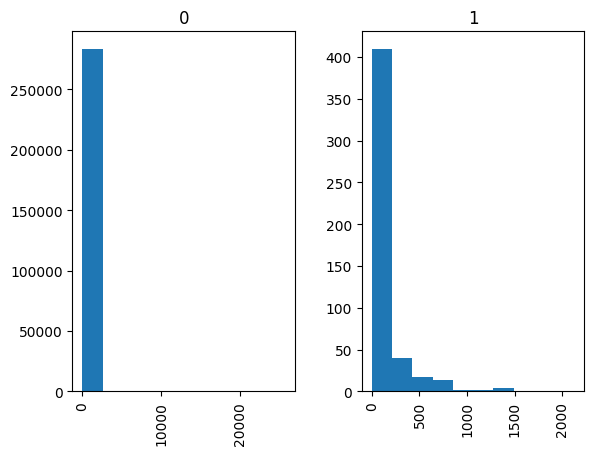

In [7]:
df['Amount'].hist(by=df['Class'])

In [8]:
print(df.groupby('Class').size())

Class
0    284315
1       492
dtype: int64


array([[<Axes: title={'center': 'Time'}>, <Axes: title={'center': 'V1'}>,
        <Axes: title={'center': 'V2'}>, <Axes: title={'center': 'V3'}>,
        <Axes: title={'center': 'V4'}>, <Axes: title={'center': 'V5'}>],
       [<Axes: title={'center': 'V6'}>, <Axes: title={'center': 'V7'}>,
        <Axes: title={'center': 'V8'}>, <Axes: title={'center': 'V9'}>,
        <Axes: title={'center': 'V10'}>, <Axes: title={'center': 'V11'}>],
       [<Axes: title={'center': 'V12'}>, <Axes: title={'center': 'V13'}>,
        <Axes: title={'center': 'V14'}>, <Axes: title={'center': 'V15'}>,
        <Axes: title={'center': 'V16'}>, <Axes: title={'center': 'V17'}>],
       [<Axes: title={'center': 'V18'}>, <Axes: title={'center': 'V19'}>,
        <Axes: title={'center': 'V20'}>, <Axes: title={'center': 'V21'}>,
        <Axes: title={'center': 'V22'}>, <Axes: title={'center': 'V23'}>],
       [<Axes: title={'center': 'V24'}>, <Axes: title={'center': 'V25'}>,
        <Axes: title={'center': 'V26'}>, <

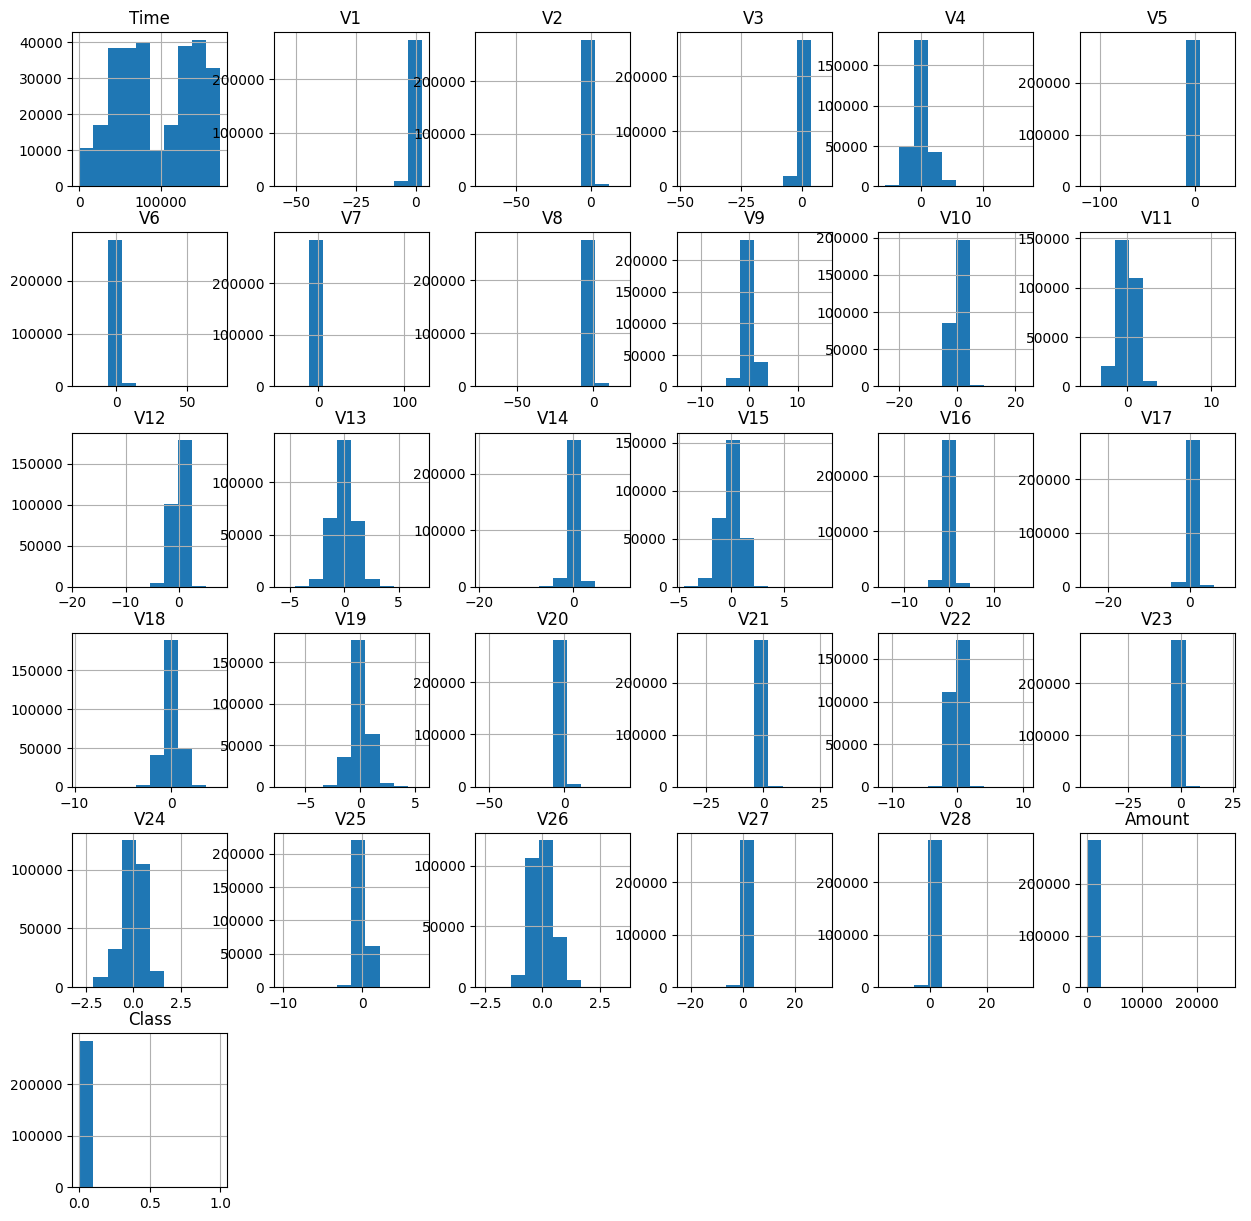

In [9]:
df.hist(figsize=(15,15))

## 6. Check the spread of fraud vs non-fraud on selected variables
#### This is done to identify variables selection which has good spread of frauds and non frauds

V9 - V10


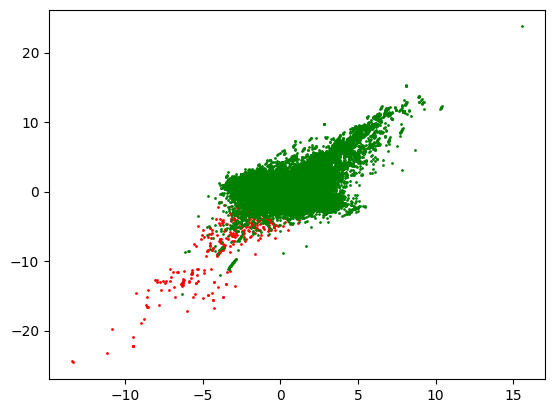

<Figure size 640x480 with 0 Axes>

In [10]:
sample = df[df['Class']==0]
fraud = df[df['Class']==1]
print('V9 - V10')
plt.scatter(fraud['V9'], fraud['V10'],s=1, color='r')
plt.scatter(sample['V9'], sample['V10'], s=1, color='g')
plt.show()
plt.clf()

V16-V17


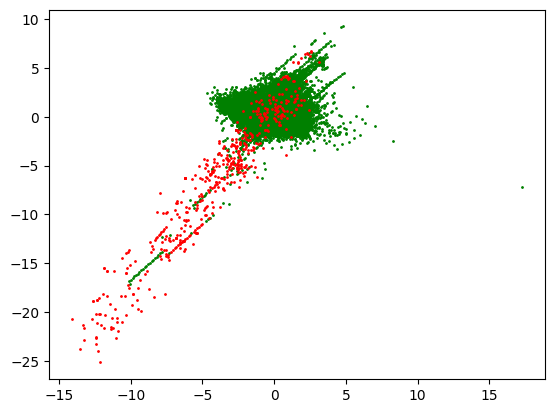

<Figure size 640x480 with 0 Axes>

In [11]:
print('V16-V17')
plt.scatter(sample['V16'], sample['V17'], s=1, color = 'g')
plt.scatter(fraud['V16'], fraud['V17'], s=1, color = 'r')
plt.show()
plt.clf()

V17 - V18


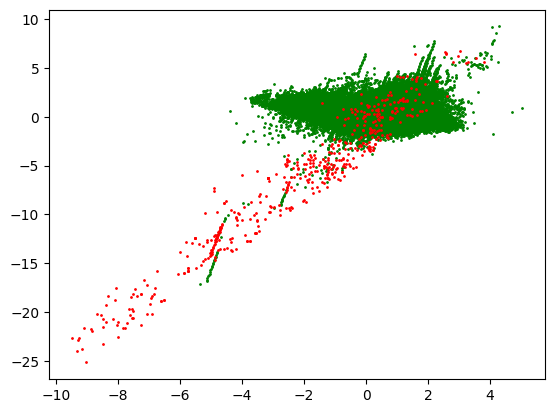

<Figure size 640x480 with 0 Axes>

In [12]:
print('V17 - V18')
plt.scatter(sample['V18'], sample['V17'], s=1, color = 'g')
plt.scatter(fraud['V18'], fraud['V17'], s=1, color = 'r')
plt.show()
plt.clf()

V1 - V3


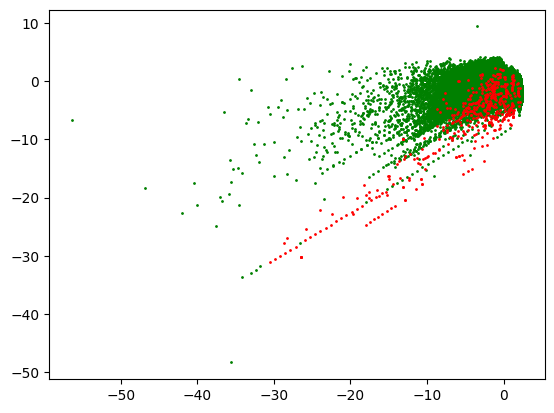

<Figure size 640x480 with 0 Axes>

In [13]:
print('V1 - V3')
plt.scatter(sample['V1'], sample['V3'], s=1, color = 'g')
plt.scatter(fraud['V1'], fraud['V3'], s=1, color = 'r')
plt.show()
plt.clf()

V1 - V2


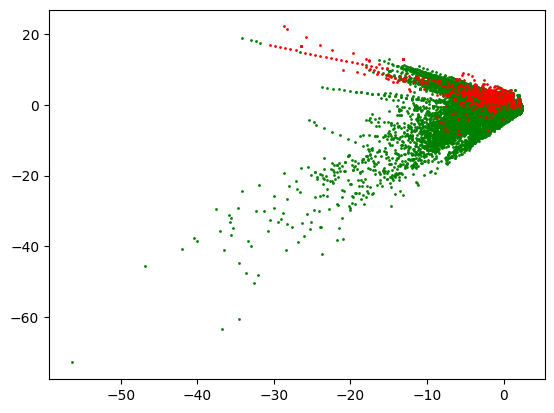

<Figure size 640x480 with 0 Axes>

In [14]:
print('V1 - V2')
plt.scatter(sample['V1'], sample['V2'], s=1, color = 'g')
plt.scatter(fraud['V1'], fraud['V2'], s=1, color = 'r')
plt.show()
plt.clf()

## 7. Split the Data and Create Low-Compute Baseline Sets

The full dataset is first split into **70% training / 20% test / 10% validation** using stratification.

For Phase 1 only, the notebook then creates smaller stratified subsets:
- **20% of the training set** for model fitting
- **20% of the test set** for development evaluation

The full validation set remains completely untouched.


In [15]:
from sklearn.model_selection import train_test_split
from pathlib import Path

FEATURES = ['Time'] + [f'V{i}' for i in range(1, 29)] + ['Amount']

# Full 70 / 20 / 10 split
development_data, validation_data = train_test_split(
    df,
    test_size=0.10,
    stratify=df["Class"],
    random_state=42
)

training_data, test_data = train_test_split(
    development_data,
    test_size=2/9,
    stratify=development_data["Class"],
    random_state=42
)

Path(OUTPUT_FOLDER).mkdir(parents=True, exist_ok=True)

training_data.to_csv(f"{OUTPUT_FOLDER}/training_data.csv", index=False)
test_data.to_csv(f"{OUTPUT_FOLDER}/test_data.csv", index=False)
validation_data.to_csv(f"{OUTPUT_FOLDER}/validation_data.csv", index=False)

# Low-compute Phase 1 subsets
baseline_training, _ = train_test_split(
    training_data,
    train_size=0.20,
    stratify=training_data["Class"],
    random_state=42
)

baseline_test, _ = train_test_split(
    test_data,
    train_size=0.20,
    stratify=test_data["Class"],
    random_state=42
)

xtrain = baseline_training[FEATURES].copy()
ytrain = baseline_training["Class"].copy()
xtest = baseline_test[FEATURES].copy()
ytest = baseline_test["Class"].copy()

print("FULL DATASET SIZES")
print("Original:", df.shape)
print("Training:", training_data.shape)
print("Test:", test_data.shape)
print("Validation (UNSEEN):", validation_data.shape)

print("\nLOW-COMPUTE PHASE 1 SIZES")
print("Baseline training:", baseline_training.shape)
print("Baseline test:", baseline_test.shape)

print("\nBaseline training class distribution:")
print(baseline_training["Class"].value_counts())

print("\nBaseline test class distribution:")
print(baseline_test["Class"].value_counts())

print("\nFull split files saved to:", OUTPUT_FOLDER)
print("Validation data is not used below.")


FULL DATASET SIZES
Original: (284807, 31)
Training: (199364, 31)
Test: (56962, 31)
Validation (UNSEEN): (28481, 31)

LOW-COMPUTE PHASE 1 SIZES
Baseline training: (39872, 31)
Baseline test: (11392, 31)

Baseline training class distribution:
Class
0    39803
1       69
Name: count, dtype: int64

Baseline test class distribution:
Class
0    11372
1       20
Name: count, dtype: int64

Full split files saved to: /content/drive/MyDrive/DS340W
Validation data is not used below.


## 8. Use Random Forest Algorithm
#### A brief about Random Forest Algorithm
Random forest classifier creates a set of decision trees from randomly selected subset of training set. It then aggregates the votes from different decision trees to decide the final class of the test object.  Random forests or random decision forests are an ensemble learning method for classification, regression and other tasks, that operate by constructing a multitude of decision trees at training time and outputting the class that is the mode of the classes (classification) or mean prediction (regression) of the individual trees. Random decision forests will avoid overfitting which will enhance the accuracy of the model on new data. This is a Bagging based algorithm which is used for reducing Overfitting in order to create strong learners for generating accurate predictions.

In [16]:
# RF Classifier explained

'''rf = RandomForestClassifier(n_estimators=100, oob_score=True, n_jobs=4)
n_estimators : integer, optional (default=10)
The number of trees in the forest.
oob_score : bool (default=False)
Whether to use out-of-bag samples to estimate the generalization accuracy.
n_jobs : integer, optional (default=1)
The number of jobs to run in parallel for both fit and predict. If -1, then the number of jobs is set to the number of cores.
'''

from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics

rfmodel = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rfmodel.fit(xtrain,ytrain)
print('model')
print(rfmodel)

ypredrf = rfmodel.predict(xtest)
print('confusion matrix')
print(metrics.confusion_matrix(ytest, ypredrf))
print('classification report')
print(metrics.classification_report(ytest, ypredrf))
print('Accuracy : %f' % (metrics.accuracy_score(ytest, ypredrf)))
print('Area under the curve : %f' % (metrics.roc_auc_score(ytest, ypredrf)))


model
RandomForestClassifier(max_depth=10, n_estimators=50, n_jobs=-1,
                       random_state=42)
confusion matrix
[[11367     5]
 [    7    13]]
classification report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11372
           1       0.72      0.65      0.68        20

    accuracy                           1.00     11392
   macro avg       0.86      0.82      0.84     11392
weighted avg       1.00      1.00      1.00     11392

Accuracy : 0.998947
Area under the curve : 0.824780


#### In the above classification report we are getting the f1-score of 89 which is the harmonic mean of precision & recall scores.
##### Recall is where the model tries to recollect the number of instances, in this case the model has been able to recollect 82% of frauds and able to classify them as frauds 96 % of the recollected events which is the precision of the model.
##### Area under the curve signifies the accuracy of the model (values between 0 & 1) where the score towards 1 indicate high predictive power.
# <font color='Red'> Note  : The numbers for recall, precision, F1 Score & Area under the curve can change for different runs of the model due to stocastic nature of the algorithms.

# 9. Use Gradient Boosting Alogrithm
#### A Brief about Gradient Boosting Algorithm
Gradient boosting is a machine learning technique for regression and classification problems, which produces a prediction model in the form of an ensemble of weak prediction models, typically decision trees. It builds the model in a stage-wise fashion like other boosting methods do, and it generalizes them by allowing optimization of an arbitrary differentiable loss function(a loss function or cost function is a function that maps an event or values of one or more variables onto a real number intuitively representing some "cost" associated with the event). This is a Boosting based algorithm which is an ensemble technique to combine weak learners to create a strong learner that can make accurate predictions.

In [17]:
# GBM Classifier explained

'''params = {'n_estimators': 500, 'max_depth': 3, 'subsample': 0.5, 'learning_rate': 0.01, 'min_samples_leaf': 1, 'random_state': 3}
clf = ensemble. GradientBoostingClassifier(**params)
n_estimators : int (default=100)
The number of boosting stages to perform. Gradient boosting is fairly robust to over-fitting, so a large number usually results in better performance.
max_depth: integer, optional (default=3)
maximum depth of the individual regression estimators. The maximum depth limits the number of nodes in the tree. The best value depends on the interaction of the input variables.
subsample: float, optional (default=1.0)
The fraction of samples to be used for fitting the individual base learners. If smaller than 1.0 this results in Stochastic Gradient Boosting. subsample interacts with the parameter n_estimators. Choosing subsample < 1.0 leads to a reduction of variance and an increase in bias.
random_state : int, RandomState instance or None, optional (default=None)
If int, random_state is the seed used by the random number generator; If RandomState instance, random_state is the random number generator; If None, the random number generator is the RandomState instance used by np.random.
learning_rate : float, optional (default=0.1)
learning rate shrinks the contribution of each tree by learning_rate. There is a trade-off between learning_rate and n_estimators.
min_samples_leaf : int, float, optional (default=1)
The minimum number of samples required to be at a leaf node:
'''

from sklearn import ensemble

params = {'n_estimators': 500, 'max_depth': 3, 'subsample': 0.5,
          'learning_rate': 0.01, 'min_samples_leaf': 1, 'random_state': 3}
clf = ensemble.GradientBoostingClassifier(**params)
clf.fit(xtrain, ytrain) #trains
y_pred = clf.predict(xtest)  #predicts
print('confusion matrix')
print(metrics.confusion_matrix(ytest, y_pred))
print('classification report')
print(metrics.classification_report(ytest, y_pred))
print("-----------------------------------------------------------------------------------------")
print("Accuracy is :")
print(metrics.accuracy_score(ytest, y_pred))
print('Area under the curve : %f' % (metrics.roc_auc_score(ytest, y_pred)))

confusion matrix
[[11368     4]
 [   10    10]]
classification report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11372
           1       0.71      0.50      0.59        20

    accuracy                           1.00     11392
   macro avg       0.86      0.75      0.79     11392
weighted avg       1.00      1.00      1.00     11392

-----------------------------------------------------------------------------------------
Accuracy is :
0.9987710674157303
Area under the curve : 0.749824


# 10. Use Extreme Gradient Boosting Alogrithm
#### A Brief about Extreme Gradient Boosting Algorithm
XGBoost is one of the implementations of Gradient Boosting concept, but what makes XGBoost unique is that it uses “a more regularized model formalization to control over-fitting, which gives it better performance,” according to the author of the algorithm, Tianqi Chen. Therefore, it helps to reduce overfitting.

In [18]:
from xgboost.sklearn import XGBClassifier

# Create the XGB classifier, xgb_model.
xgb_model = XGBClassifier(n_estimators=75, max_depth=4, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, eval_metric='error', tree_method='hist', random_state=42, n_jobs=-1)


In [19]:
# List the default parameters.
print(xgb_model.get_xgb_params())

{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8, 'device': None, 'eval_metric': 'error', 'gamma': None, 'grow_policy': None, 'interaction_constraints': None, 'learning_rate': 0.1, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 4, 'max_leaves': None, 'min_child_weight': None, 'monotone_constraints': None, 'multi_strategy': None, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.8, 'tree_method': 'hist', 'validate_parameters': None, 'verbosity': None}


In [20]:
# Train and evaluate.
# The test set is used for development monitoring.
# The final validation set remains untouched.
xgb_model.fit(
    xtrain,
    ytrain,
    eval_set=[(xtrain, ytrain), (xtest, ytest)],
    verbose=False
)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='error', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=75,
              n_jobs=-1, num_parallel_tree=None, ...)

In [21]:
from sklearn import metrics
import warnings
warnings.filterwarnings("ignore")

y_pred = xgb_model.predict(xtest)  #predicts
print('confusion matrix')
print(metrics.confusion_matrix(ytest, y_pred))
print('classification report')
print(metrics.classification_report(ytest, y_pred))
print("-----------------------------------------------------------------------------------------")
print("Accuracy is :")
print(metrics.accuracy_score(ytest, y_pred))
print('Area under the curve : %f' % (metrics.roc_auc_score(ytest, y_pred)))

confusion matrix
[[11371     1]
 [    7    13]]
classification report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11372
           1       0.93      0.65      0.76        20

    accuracy                           1.00     11392
   macro avg       0.96      0.82      0.88     11392
weighted avg       1.00      1.00      1.00     11392

-----------------------------------------------------------------------------------------
Accuracy is :
0.9992977528089888
Area under the curve : 0.824956


#### As we can see, the F1 score and Area under the curve are higher compared to previous model.

# 11. Select a Smaller Set of Variables for Model Building

This keeps IBM's reduced-feature experiment, but uses the existing **training and test datasets** rather than re-splitting the complete dataset. The final validation set remains untouched.


In [22]:
REDUCED_FEATURES = ['V9', 'V10', 'V16', 'V17', 'V18', 'Amount']

xtrain = baseline_training[REDUCED_FEATURES].copy()
ytrain = baseline_training["Class"].copy()
xtest = baseline_test[REDUCED_FEATURES].copy()
ytest = baseline_test["Class"].copy()

print("xtrain shape:", xtrain.shape)
print("xtest shape:", xtest.shape)


xtrain shape: (39872, 6)
xtest shape: (11392, 6)


In [23]:
'''Random Forest Classifier on reduced dimensions data'''

from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics

rfmodel = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rfmodel.fit(xtrain,ytrain)
print('model')
print(rfmodel)

ypredrf = rfmodel.predict(xtest)
print('confusion matrix')
print(metrics.confusion_matrix(ytest, ypredrf))
print('classification report')
print(metrics.classification_report(ytest, ypredrf))
print('Accuracy : %f' % (metrics.accuracy_score(ytest, ypredrf)))
print('Area under the curve : %f' % (metrics.roc_auc_score(ytest, ypredrf)))


model
RandomForestClassifier(max_depth=10, n_estimators=50, n_jobs=-1,
                       random_state=42)
confusion matrix
[[11367     5]
 [   10    10]]
classification report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11372
           1       0.67      0.50      0.57        20

    accuracy                           1.00     11392
   macro avg       0.83      0.75      0.79     11392
weighted avg       1.00      1.00      1.00     11392

Accuracy : 0.998683
Area under the curve : 0.749780


#### The F1 score has reduced with fewer variables along with Area under the curve

In [24]:
'''Gradient Boost Algorithm on reduced dimensions data'''

from sklearn import ensemble

params = {'n_estimators': 500, 'max_depth': 3, 'subsample': 0.5,
          'learning_rate': 0.01, 'min_samples_leaf': 1, 'random_state': 3}
clf = ensemble.GradientBoostingClassifier(**params)
clf.fit(xtrain, ytrain) #trains
y_pred = clf.predict(xtest)  #predicts
print('confusion matrix')
print(metrics.confusion_matrix(ytest, y_pred))
print('classification report')
print(metrics.classification_report(ytest, y_pred))
print("-----------------------------------------------------------------------------------------")
print("Accuracy is :")
print(metrics.accuracy_score(ytest, y_pred))
print('Area under the curve : %f' % (metrics.roc_auc_score(ytest, y_pred)))

confusion matrix
[[11367     5]
 [   10    10]]
classification report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11372
           1       0.67      0.50      0.57        20

    accuracy                           1.00     11392
   macro avg       0.83      0.75      0.79     11392
weighted avg       1.00      1.00      1.00     11392

-----------------------------------------------------------------------------------------
Accuracy is :
0.9986832865168539
Area under the curve : 0.749780


#### Reduction in the F1 score with fewer variables.

In [25]:
'''Extreme Gradient Boost Algorithm on reduced dimensions data'''

from xgboost.sklearn import XGBClassifier

# Create the XGB classifier, xgb_model.
xgb_model = XGBClassifier(n_estimators=75, max_depth=4, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, eval_metric='error', tree_method='hist', random_state=42, n_jobs=-1)
# List the default parameters.
print(xgb_model.get_xgb_params())


{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8, 'device': None, 'eval_metric': 'error', 'gamma': None, 'grow_policy': None, 'interaction_constraints': None, 'learning_rate': 0.1, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 4, 'max_leaves': None, 'min_child_weight': None, 'monotone_constraints': None, 'multi_strategy': None, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.8, 'tree_method': 'hist', 'validate_parameters': None, 'verbosity': None}


In [26]:
# Train and evaluate.
# The test set is used for development monitoring.
# The final validation set remains untouched.
xgb_model.fit(
    xtrain,
    ytrain,
    eval_set=[(xtrain, ytrain), (xtest, ytest)],
    verbose=False
)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='error', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=75,
              n_jobs=-1, num_parallel_tree=None, ...)

In [27]:
from sklearn import metrics
import warnings
warnings.filterwarnings("ignore")

y_pred = xgb_model.predict(xtest)  #predicts
print('confusion matrix')
print(metrics.confusion_matrix(ytest, y_pred))
print('classification report')
print(metrics.classification_report(ytest, y_pred))
print("-----------------------------------------------------------------------------------------")
print("Accuracy is :")
print(metrics.accuracy_score(ytest, y_pred))
print('Area under the curve : %f' % (metrics.roc_auc_score(ytest, y_pred)))

confusion matrix
[[11367     5]
 [   10    10]]
classification report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11372
           1       0.67      0.50      0.57        20

    accuracy                           1.00     11392
   macro avg       0.83      0.75      0.79     11392
weighted avg       1.00      1.00      1.00     11392

-----------------------------------------------------------------------------------------
Accuracy is :
0.9986832865168539
Area under the curve : 0.749780


#### Higher F1 score compared to Gradient Boosting Model

# 12. Random Under Sampling

IBM's undersampling experiment is preserved, but undersampling is now applied **only to the training dataset**.

The test set stays in its original natural class distribution, and the final validation set remains untouched.


In [28]:
train_nonfraud = baseline_training[baseline_training['Class'] == 0]
train_fraud = baseline_training[baseline_training['Class'] == 1]

sample_nonfraud = train_nonfraud.sample(frac=0.10, random_state=42)

undersampled_train = pd.concat(
    [sample_nonfraud, train_fraud],
    axis=0
).sample(frac=1, random_state=42).reset_index(drop=True)

print("Undersampled baseline training distribution:")
print(undersampled_train["Class"].value_counts())


Undersampled baseline training distribution:
Class
0    3980
1      69
Name: count, dtype: int64


In [29]:
import warnings
warnings.filterwarnings("ignore")

xtrain = undersampled_train[FEATURES].copy()
ytrain = undersampled_train["Class"].copy()

xtest = baseline_test[FEATURES].copy()
ytest = baseline_test["Class"].copy()

print("Undersampled xtrain shape:", xtrain.shape)
print("Baseline xtest shape:", xtest.shape)


Undersampled xtrain shape: (4049, 30)
Baseline xtest shape: (11392, 30)


In [30]:
'''Random Forest Classifier on undersampled data'''

from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics

rfmodel = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rfmodel.fit(xtrain,ytrain)
print('model')
print(rfmodel)

ypredrf = rfmodel.predict(xtest)
print('confusion matrix')
print(metrics.confusion_matrix(ytest, ypredrf))
print('classification report')
print(metrics.classification_report(ytest, ypredrf))
print('Accuracy : %f' % (metrics.accuracy_score(ytest, ypredrf)))
print('Area under the curve : %f' % (metrics.roc_auc_score(ytest, ypredrf)))


model
RandomForestClassifier(max_depth=10, n_estimators=50, n_jobs=-1,
                       random_state=42)
confusion matrix
[[11361    11]
 [    7    13]]
classification report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11372
           1       0.54      0.65      0.59        20

    accuracy                           1.00     11392
   macro avg       0.77      0.82      0.80     11392
weighted avg       1.00      1.00      1.00     11392

Accuracy : 0.998420
Area under the curve : 0.824516


#### we can see an increase in F1 score which indicates that random under sample can give a lift in the accuracy. However we need to do random sampling multiple times for training the model and then use it on the new data for better results.

In [31]:
'''Gradient Boost Algorithm on undersampled data'''

from sklearn import ensemble

params = {'n_estimators': 650, 'max_depth': 3, 'subsample': 0.5,
          'learning_rate': 0.01, 'min_samples_leaf': 1, 'random_state': 3}
clf = ensemble.GradientBoostingClassifier(**params)
clf.fit(xtrain, ytrain) #trains
y_pred = clf.predict(xtest)  #predicts
print('confusion matrix')
print(metrics.confusion_matrix(ytest, y_pred))
print('classification report')
print(metrics.classification_report(ytest, y_pred))
print("-----------------------------------------------------------------------------------------")
print("Accuracy is :")
print(metrics.accuracy_score(ytest, y_pred))
print('Area under the curve : %f' % (metrics.roc_auc_score(ytest, y_pred)))

confusion matrix
[[11352    20]
 [    7    13]]
classification report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11372
           1       0.39      0.65      0.49        20

    accuracy                           1.00     11392
   macro avg       0.70      0.82      0.74     11392
weighted avg       1.00      1.00      1.00     11392

-----------------------------------------------------------------------------------------
Accuracy is :
0.9976299157303371
Area under the curve : 0.824121


#### There is an increase in the F1 score for this sampling technique with 10% data of non-frauds and 100% frauds.

In [32]:
'''Extreme Gradient Boost Algorithm on reduced dimensions data'''

from xgboost.sklearn import XGBClassifier

# Create the XGB classifier, xgb_model.
xgb_model = XGBClassifier(n_estimators=75, max_depth=4, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, eval_metric='error', tree_method='hist', random_state=42, n_jobs=-1)

# List the default parameters.
print(xgb_model.get_xgb_params())


{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8, 'device': None, 'eval_metric': 'error', 'gamma': None, 'grow_policy': None, 'interaction_constraints': None, 'learning_rate': 0.1, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 4, 'max_leaves': None, 'min_child_weight': None, 'monotone_constraints': None, 'multi_strategy': None, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.8, 'tree_method': 'hist', 'validate_parameters': None, 'verbosity': None}


In [33]:
# Train and evaluate.
# The test set is used for development monitoring.
# The final validation set remains untouched.
xgb_model.fit(
    xtrain,
    ytrain,
    eval_set=[(xtrain, ytrain), (xtest, ytest)],
    verbose=False
)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='error', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=75,
              n_jobs=-1, num_parallel_tree=None, ...)

In [34]:
from sklearn import metrics
import warnings
warnings.filterwarnings("ignore")

y_pred = xgb_model.predict(xtest)  #predicts
print('confusion matrix')
print(metrics.confusion_matrix(ytest, y_pred))
print('classification report')
print(metrics.classification_report(ytest, y_pred))
print("-----------------------------------------------------------------------------------------")
print("Accuracy is :")
print(metrics.accuracy_score(ytest, y_pred))
print('Area under the curve : %f' % (metrics.roc_auc_score(ytest, y_pred)))

confusion matrix
[[11356    16]
 [    6    14]]
classification report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11372
           1       0.47      0.70      0.56        20

    accuracy                           1.00     11392
   macro avg       0.73      0.85      0.78     11392
weighted avg       1.00      1.00      1.00     11392

-----------------------------------------------------------------------------------------
Accuracy is :
0.9980688202247191
Area under the curve : 0.849297


#### Higher F1 score comapred to Gradient Boosting Model.

# 13. SMOTE (Synthetic Minority Over-sampling Technique)

SMOTE is applied **only to the training dataset**.  
The test dataset is not resampled, and the final validation dataset remains unseen.


In [35]:
!pip -q install imbalanced-learn


In [36]:
from collections import Counter
from imblearn.over_sampling import SMOTE

X_train_original = baseline_training[FEATURES].copy()
y_train_original = baseline_training["Class"].copy()

minority_count = int((y_train_original == 1).sum())
target_minority = min(max(minority_count * 2, minority_count + 1), 300)

sm = SMOTE(
    random_state=42,
    sampling_strategy={1: target_minority},
    k_neighbors=3
)

X_res, y_res = sm.fit_resample(X_train_original, y_train_original)

print("Original baseline training distribution:")
print(Counter(y_train_original))
print("\nSMOTE baseline training distribution:")
print(Counter(y_res))


Original baseline training distribution:
Counter({0: 39803, 1: 69})

SMOTE baseline training distribution:
Counter({0: 39803, 1: 138})


In [37]:
xtrain = X_res.copy()
ytrain = y_res.copy()

xtest = baseline_test[FEATURES].copy()
ytest = baseline_test["Class"].copy()

print("SMOTE xtrain shape:", xtrain.shape)
print("Baseline xtest shape:", xtest.shape)
print("Final validation set remains unused.")


SMOTE xtrain shape: (39941, 30)
Baseline xtest shape: (11392, 30)
Final validation set remains unused.


In [38]:
'''Random Forest Classifier on resampled data'''

from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics

rfmodel = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rfmodel.fit(xtrain,ytrain)
print('model')
print(rfmodel)

ypredrf = rfmodel.predict(xtest)
print('confusion matrix')
print(metrics.confusion_matrix(ytest, ypredrf))
print('classification report')
print(metrics.classification_report(ytest, ypredrf))
print('Accuracy : %f' % (metrics.accuracy_score(ytest, ypredrf)))
print('Area under the curve : %f' % (metrics.roc_auc_score(ytest, ypredrf)))


model
RandomForestClassifier(max_depth=10, n_estimators=50, n_jobs=-1,
                       random_state=42)
confusion matrix
[[11367     5]
 [    7    13]]
classification report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11372
           1       0.72      0.65      0.68        20

    accuracy                           1.00     11392
   macro avg       0.86      0.82      0.84     11392
weighted avg       1.00      1.00      1.00     11392

Accuracy : 0.998947
Area under the curve : 0.824780


#### We can see an increase in F1 score and the Area under the curve. This is the advantage of synthetic over sampling technique which has given a good lift in accuracy.

In [39]:
'''Gradient Boost Algorithm on resampled data'''

from sklearn import ensemble

params = {'n_estimators': 500, 'max_depth': 3, 'subsample': 0.5,
          'learning_rate': 0.01, 'min_samples_leaf': 1, 'random_state': 3}
clf = ensemble.GradientBoostingClassifier(**params)
clf.fit(xtrain, ytrain) #trains
y_pred = clf.predict(xtest)  #predicts
print('confusion matrix')
print(metrics.confusion_matrix(ytest, y_pred))
print('classification report')
print(metrics.classification_report(ytest, y_pred))
print("-----------------------------------------------------------------------------------------")
print("Accuracy is :")
print(metrics.accuracy_score(ytest, y_pred))
print('Area under the curve : %f' % (metrics.roc_auc_score(ytest, y_pred)))

confusion matrix
[[11364     8]
 [    7    13]]
classification report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11372
           1       0.62      0.65      0.63        20

    accuracy                           1.00     11392
   macro avg       0.81      0.82      0.82     11392
weighted avg       1.00      1.00      1.00     11392

-----------------------------------------------------------------------------------------
Accuracy is :
0.9986832865168539
Area under the curve : 0.824648


#### There's an increase in precision, F1 score & Area under the curve using SMOTE and resampling the data.

In [40]:
'''Extreme Gradient Boost Algorithm on reduced dimensions data'''

from xgboost.sklearn import XGBClassifier

# Create the XGB classifier, xgb_model.
xgb_model = XGBClassifier(n_estimators=75, max_depth=4, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, eval_metric='error', tree_method='hist', random_state=42, n_jobs=-1)

# List the default parameters.
print(xgb_model.get_xgb_params())


{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8, 'device': None, 'eval_metric': 'error', 'gamma': None, 'grow_policy': None, 'interaction_constraints': None, 'learning_rate': 0.1, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 4, 'max_leaves': None, 'min_child_weight': None, 'monotone_constraints': None, 'multi_strategy': None, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.8, 'tree_method': 'hist', 'validate_parameters': None, 'verbosity': None}


In [41]:
# Train and evaluate.
# The test set is used for development monitoring.
# The final validation set remains untouched.
xgb_model.fit(
    xtrain,
    ytrain,
    eval_set=[(xtrain, ytrain), (xtest, ytest)],
    verbose=False
)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='error', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=75,
              n_jobs=-1, num_parallel_tree=None, ...)

In [42]:
from sklearn import metrics
import warnings
warnings.filterwarnings("ignore")

y_pred = xgb_model.predict(xtest)  #predicts
print('confusion matrix')
print(metrics.confusion_matrix(ytest, y_pred))
print('classification report')
print(metrics.classification_report(ytest, y_pred))
print("-----------------------------------------------------------------------------------------")
print("Accuracy is :")
print(metrics.accuracy_score(ytest, y_pred))
print('Area under the curve : %f' % (metrics.roc_auc_score(ytest, y_pred)))

confusion matrix
[[11369     3]
 [    6    14]]
classification report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11372
           1       0.82      0.70      0.76        20

    accuracy                           1.00     11392
   macro avg       0.91      0.85      0.88     11392
weighted avg       1.00      1.00      1.00     11392

-----------------------------------------------------------------------------------------
Accuracy is :
0.9992099719101124
Area under the curve : 0.849868


#### XGBoost has given high F1 score when compared with Gradient Boosting Model

### Conclusion

This notebook preserves the IBM baseline workflow while adapting it to the full ULB dataset and the course-required 70% training / 20% test / 10% final validation split.

Sampling methods are applied only to the training data. Model comparisons are made on the test data. The final validation dataset remains unseen and should only be used after development and debugging are complete.
